# Understanding the C-MAPSS Turbofan Data

I just received this dataset and I'm not modeling anything yet. Before that's worth doing, I need
to answer three questions, in order:

1. What does a row actually represent?
2. What am I predicting, and is the target even learnable everywhere?
3. Which of the 21 sensors carry real signal, and is that signal trustworthy across the four sub-datasets?

I'll let those questions drive the work and stop each thread the moment it's answered. The goal here is
a defensible understanding of the data, not a pile of plots.

## 1. What do I actually have?

NASA ships these as space-delimited text files with no header row. First thing: load one and look at it
raw, before trusting any wrapper code.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RAW = Path('../data/raw')

raw = pd.read_csv(RAW / 'train_FD001.txt', sep=r'\s+', header=None)
print('shape:', raw.shape)
raw.head()

shape: (20631, 26)


,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


26 columns. From the dataset documentation the layout is: engine unit number, time in cycles, three
operational settings, then 21 sensor readings. The sensors aren't labeled with what they physically
measure — that's fine. I'll treat them as anonymous signals and let the data tell me which ones matter
rather than reasoning from physics I don't have.

In [2]:
cols = ['unit', 'cycle', 'op1', 'op2', 'op3'] + [f's{i}' for i in range(1, 22)]
df = raw.copy()
df.columns = cols

# one row = one engine at one cycle. Sanity check the structure.
print('engines:', df['unit'].nunique())
print('rows per engine:', df.groupby('unit').size().describe()[['min', 'mean', 'max']].round().to_dict())
df[['s2', 's7', 's11', 's1']].describe().round(2)

engines: 100
rows per engine: {'min': 128.0, 'mean': 206.0, 'max': 362.0}


,s2,s7,s11,s1
count,20631.00,20631.00,20631.00,20631.00
mean,642.68,553.37,47.54,518.67
std,0.50,0.89,0.27,0.00
min,641.21,549.85,46.85,518.67
25%,642.33,552.81,47.35,518.67
50%,642.64,553.44,47.51,518.67
75%,643.00,554.01,47.70,518.67
max,644.53,556.06,48.53,518.67


## 2. What am I predicting?

There's no RUL (remaining useful life) column. But these are run-to-failure engines — each one is recorded
until it breaks. So for any row, the remaining life is just: (that engine's final cycle) minus (the current
cycle). The last row of every engine has RUL = 0.

Before I compute it, I want to see how long engines live — that decides whether the target needs capping.

{'count': 100.0, 'mean': 206.0, 'std': 46.0, 'min': 128.0, '25%': 177.0, '50%': 199.0, '75%': 229.0, 'max': 362.0}


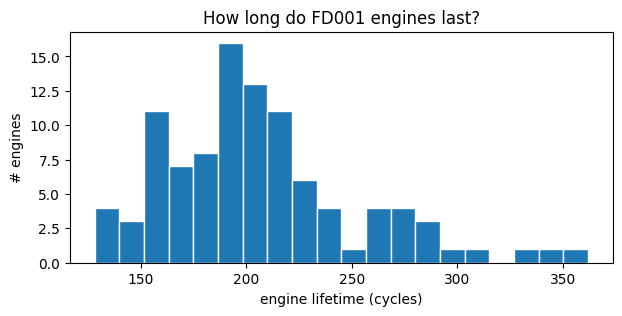

In [3]:
life = df.groupby('unit')['cycle'].max()
print(life.describe().round().to_dict())

df['rul'] = df.groupby('unit')['cycle'].transform('max') - df['cycle']

plt.figure(figsize=(7, 3))
plt.hist(life, bins=20, edgecolor='white')
plt.xlabel('engine lifetime (cycles)')
plt.ylabel('# engines')
plt.title('How long do FD001 engines last?')
plt.show()

Engines live anywhere from ~130 to ~360 cycles. That range is the reason I won't use raw RUL as the target.

Early in an engine's life it's healthy and the sensors barely move. There is nothing in the data that
distinguishes "300 cycles left" from "250 cycles left" — both look like a perfectly healthy engine. Asking a
model to predict 300 is asking it to learn a number that isn't present in the inputs. So I cap RUL at a
point where degradation is actually observable. 125 is the conventional choice for C-MAPSS and I'll confirm
it's sensible once I've looked at when sensors start moving.

**If asked to defend this:** the cap isn't a trick to make the error look smaller. It encodes a real property
of the data — RUL is only estimable once degradation begins, so flat-lining the label in the healthy region
stops the model from chasing signal that doesn't exist.

In [4]:
RUL_CAP = 125
df['rul'] = df['rul'].clip(upper=RUL_CAP)

## 3. Which sensors carry signal?

I'll plot a few raw sensor trajectories against cycle for a handful of engines. What I'm looking for: does the
sensor drift as the engine ages (useful) or sit flat (useless)?

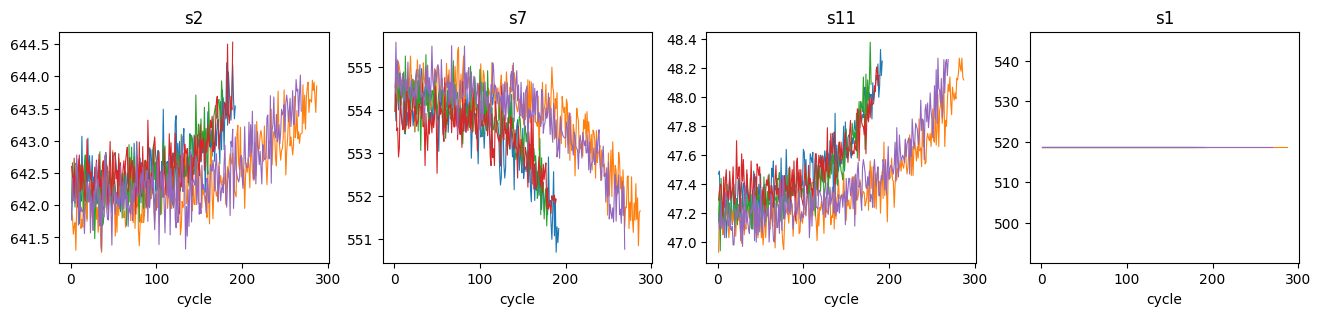

In [5]:
units = df['unit'].unique()[:5]
fig, ax = plt.subplots(1, 4, figsize=(16, 3))
for a, s in zip(ax, ['s2', 's7', 's11', 's1']):
    for u in units:
        g = df[df['unit'] == u]
        a.plot(g['cycle'], g[s], lw=0.8)
    a.set_title(s)
    a.set_xlabel('cycle')
plt.show()

s2, s7 and s11 drift steadily as the engine ages — that's the degradation showing up. s1 is a flat line: it
never moves, so it can't possibly tell me anything about wear.

Rather than eyeball all 21, I'll catch the dead ones at once by looking at standard deviation. The useless
sensors cluster near zero; there's usually an obvious gap between them and the rest.

In [6]:
sensor_cols = [f's{i}' for i in range(1, 22)]
sd = df[sensor_cols].std().sort_values()
print(sd.round(4).to_string())

# the near-constant sensors sit well below everything else — cut in the gap
dead = sd[sd < 1e-2].index.tolist()
keep = [s for s in sensor_cols if s not in dead]
print('\ndrop:', dead)
print('keep:', keep)

s1      0.0000
s10     0.0000
s19     0.0000
s18     0.0000
s16     0.0000
s5      0.0000
s6      0.0014
s15     0.0375
s8      0.0710
s13     0.0719
s21     0.1083
s20     0.1807
s11     0.2671
s2      0.5001
s12     0.7376
s7      0.8851
s17     1.5488
s3      6.1311
s4      9.0006
s14    19.0762
s9     22.0829

drop: ['s1', 's10', 's19', 's18', 's16', 's5', 's6']
keep: ['s2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']


**If asked to defend this:** I'm not dropping sensors because a correlation score said so — I'm dropping the
ones that are physically constant in this data and therefore carry zero information by construction. The
variance cutoff is just a fast way to find them; the sorted list shows the gap is unambiguous.

## 4. The thing that actually makes or breaks this project

FD001 was the easy case — one operating condition. Now I open FD002, where engines run under varied
conditions. The same sensors that trended cleanly above will look completely different here. Before I assume
anything is wrong, I'll look at the operating settings, because that's the only thing that changed.

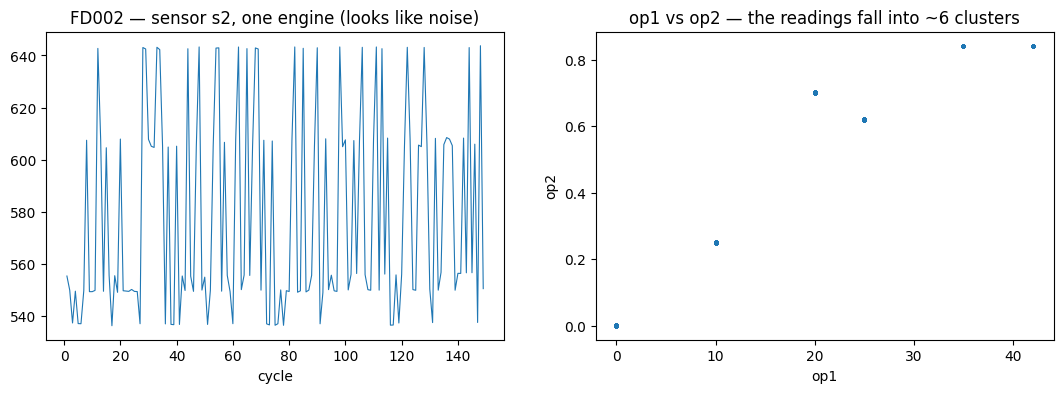

In [7]:
df2 = pd.read_csv(RAW / 'train_FD002.txt', sep=r'\s+', header=None)
df2.columns = cols

u = df2['unit'].unique()[0]
g = df2[df2['unit'] == u]

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(g['cycle'], g['s2'], lw=0.8)
ax[0].set_title('FD002 — sensor s2, one engine (looks like noise)')
ax[0].set_xlabel('cycle')
ax[1].scatter(df2['op1'], df2['op2'], s=4, alpha=0.08)
ax[1].set_title('op1 vs op2 — the readings fall into ~6 clusters')
ax[1].set_xlabel('op1'); ax[1].set_ylabel('op2')
plt.show()

There it is. The sensor on the left looks like random noise — but the scatter on the right explains why. The
engine constantly switches between about six distinct operating conditions, and **each condition has its own
sensor baseline.** A temperature reading at cruise simply means something different than the same reading at
takeoff. Stack six baselines on top of each other and a clean degradation trend turns into hash.

This is the single most important decision in the whole project:

> For FD002 and FD004, I must normalize each sensor *within its operating regime*, not globally. For FD001
> and FD003 there's only one regime, so a single global normalization is fine.

Get this wrong and every rolling mean, every slope, every model downstream is built on garbage. Let me prove
the fix works before committing to it.

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# recover the 6 operating regimes from the settings
# scale first — op1/op2/op3 are on very different ranges, so raw-distance
# KMeans would be dominated by whichever setting has the largest variance
op_sc = StandardScaler().fit_transform(df2[['op1', 'op2', 'op3']])
df2['regime'] = KMeans(n_clusters=6, n_init=10, random_state=0).fit_predict(op_sc)

# z-score s2 within its own regime instead of across all of them
df2['s2_norm'] = df2.groupby('regime')['s2'].transform(lambda x: (x - x.mean()) / x.std())

g = df2[df2['unit'] == u]
plt.figure(figsize=(7, 3))
plt.plot(g['cycle'], g['s2_norm'], lw=0.9)
plt.xlabel('cycle')
plt.title('FD002 s2 after per-regime normalization — the trend is back')
plt.show()

**If asked to defend this:** this is precisely why a naive model trained on FD002 raw sensors performs badly
— it isn't a model problem, it's that the features mix six incompatible scales. Per-regime normalization is
the cheapest possible fix and the plot shows it recovers the signal.

## 5. What features does the signal justify?

Here's what I now know about the degradation signal, from actually looking at it:

- it's **gradual** — it builds over many cycles, not in jumps
- it's **roughly monotone** — once an engine starts degrading it keeps going
- it's **buried in cycle-to-cycle noise**

That points to exactly two derived quantities per kept sensor, plus the value itself:

1. the normalized sensor value (the current state)
2. a **rolling mean** — smooths the noise so the trend is legible
3. a **rolling slope** — the rate of degradation, which is what actually changes near failure

That's 42 features for the 14 kept sensors, and I can say why each one exists.

I am deliberately **not** adding rolling min/max/std, FFT/frequency features, lagged copies, sensor-pair
interactions, or a PCA health index. None of them are motivated by anything I've seen — they'd just be me
enumerating every feature I know how to compute. Unused features add noise, slow things down, and make the
model harder to trust and explain. If the model later fails in a specific, identifiable way, I'll add the one
feature that addresses that failure and I'll be able to justify it.

Normalization (per-regime for FD002/FD004, global for FD001/FD003) is built into `add_features`, so the implementation matches the Section 4 decision rather than relying on the caller to handle it.

In [ ]:
def add_features(d, sensors, dataset_name, window=20, stats=None):
    """Return (df_with_features, stats_dict).

    3 features per sensor: normalized value, rolling mean, rolling slope.
    Normalization is fitted on training data (stats=None) and reused on val/test
    by passing the returned stats dict — no refitting on held-out data.

    FD002/FD004: 6-regime KMeans on scaled op settings, z-score within regime.
    FD001/FD003: single global z-score per sensor.
    """
    from sklearn.preprocessing import StandardScaler
    from sklearn.cluster import KMeans

    d = d.sort_values(['unit', 'cycle']).copy()
    multi = dataset_name in ('FD002', 'FD004')

    # --- fit or reuse normalization statistics ---
    if stats is None:
        if multi:
            op_sc = StandardScaler().fit(d[['op1', 'op2', 'op3']])
            km    = KMeans(n_clusters=6, n_init=10, random_state=0)
            km.fit(op_sc.transform(d[['op1', 'op2', 'op3']]))
            d['_r'] = km.predict(op_sc.transform(d[['op1', 'op2', 'op3']]))
            s_mean = {s: d.groupby('_r')[s].mean().to_dict() for s in sensors}
            s_std  = {s: d.groupby('_r')[s].std().fillna(1).replace(0, 1).to_dict()
                      for s in sensors}
            stats  = {'multi': True, 'op_sc': op_sc, 'km': km,
                      's_mean': s_mean, 's_std': s_std}
        else:
            s_mean = {s: float(d[s].mean())              for s in sensors}
            s_std  = {s: float(max(d[s].std(), 1e-9))    for s in sensors}
            stats  = {'multi': False, 's_mean': s_mean, 's_std': s_std}
    else:
        if stats['multi']:
            d['_r'] = stats['km'].predict(
                          stats['op_sc'].transform(d[['op1', 'op2', 'op3']]))

    # --- normalize ---
    for s in sensors:
        if stats['multi']:
            mu  = d['_r'].map(stats['s_mean'][s]).fillna(0)
            sig = d['_r'].map(stats['s_std'][s]).fillna(1)
        else:
            mu, sig = stats['s_mean'][s], stats['s_std'][s]
        d[f'{s}_n'] = (d[s] - mu) / sig

    # --- rolling features on the normalized signal ---
    g = d.groupby('unit')
    for s in sensors:
        sn = f'{s}_n'
        d[f'{s}_mean']  = g[sn].transform(
            lambda x: x.rolling(window, min_periods=1).mean())
        d[f'{s}_slope'] = g[sn].transform(
            lambda x: x.rolling(window, min_periods=2)
                       .apply(lambda w: np.polyfit(np.arange(len(w)), w, 1)[0], raw=True))

    if '_r' in d.columns:
        d = d.drop(columns=['_r'])
    return d.fillna(0), stats


feat_df, norm_stats = add_features(df, keep, 'FD001', window=20)
feature_cols = ([f'{s}_n'     for s in keep] +
                [f'{s}_mean'  for s in keep] +
                [f'{s}_slope' for s in keep])
print(f'{len(feature_cols)} features from {len(keep)} sensors')

## 6. Do these features actually carry signal?

Quick gut check before declaring victory: fit a plain model on these features and compare it to the dumbest
possible baseline — predicting the mean RUL for everything. If the features don't beat that, they're worthless.

Split by engine (not by row) so no engine appears in both train and validation.

In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

engines = feat_df['unit'].unique()
train_e, val_e = engines[:80], engines[80:]
tr = feat_df[feat_df['unit'].isin(train_e)]
va = feat_df[feat_df['unit'].isin(val_e)]

model = RandomForestRegressor(n_estimators=100, random_state=0, n_jobs=-1)
model.fit(tr[feature_cols], tr['rul'])
pred = model.predict(va[feature_cols])

rmse = mean_squared_error(va['rul'], pred) ** 0.5
baseline = mean_squared_error(va['rul'], np.full(len(va), tr['rul'].mean())) ** 0.5
print(f'predict-the-mean baseline RMSE : {baseline:5.1f} cycles')
print(f'minimal feature model RMSE     : {rmse:5.1f} cycles')

predict-the-mean baseline RMSE :  41.5 cycles
minimal feature model RMSE     :  16.9 cycles


The big drop from the baseline confirms the features carry real degradation signal — that's all this check is
for.

**Important caveat so I don't mislead myself:** this RMSE is computed over *all* rows, including the easy
healthy-plateau ones. It is a signal check, not a real score. The proper evaluation predicts RUL only at the
last observed cycle of each test engine and compares to NASA's ground-truth RUL file, using their asymmetric
scoring function. That belongs in the modeling notebook, not here.

## What I decided, and why

- **A row is one engine at one cycle.** 100 engines in FD001, run to failure.
- **Target = capped RUL (125).** Beyond the cap every engine looks healthy and RUL isn't estimable, so a
  higher cap just trains the model on noise.
- **Dropped the constant sensors.** They're flat by construction and carry zero information; the variance gap
  makes the cut obvious.
- **Per-regime normalization for FD002/FD004.** The six operating conditions each have their own sensor
  baseline; normalizing within regime is what turns apparent noise back into a degradation trend. This is the
  decision the whole project hinges on.
- **42 features: normalized value + rolling mean + rolling slope per sensor.** Each is motivated by an
  observed property of the signal (gradual, monotone, noisy). Everything else is deferred until a model
  failure justifies it.

**Next:** modeling, with a real evaluation protocol (last-cycle test prediction + NASA score). The data
understanding is done.